## Preliminares

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import PowerTransformer
import sklearn.impute as skl_imp
from sklearn.experimental import enable_iterative_imputer # Necesario para usar skl_imp, no borrar
from src.config import data_folder
from src.funcionesTransform import *

In [2]:
# Abrir archivo raw_data
df = pd.read_parquet(f"{data_folder}/raw_data.parquet")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18028 entries, 0 to 18027
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Date                    18028 non-null  datetime64[ns]
 1   Close                   18028 non-null  float64       
 2   Dividends               18028 non-null  float64       
 3   Ticker                  18028 non-null  object        
 4   Sector                  18028 non-null  object        
 5   DateAdded               18028 non-null  object        
 6   TotalRevenue            18028 non-null  float64       
 7   GrossProfit             17767 non-null  float64       
 8   OperatingIncome         18028 non-null  float64       
 9   NetIncome               17989 non-null  float64       
 10  EBITDA                  18028 non-null  float64       
 11  BasicAverageShares      17977 non-null  float64       
 12  CashAndCashEquivalents  17989 non-null  float6

In [3]:
# Valores missing
df.apply(lambda x: x.isna().sum() / len(x)).sort_values(ascending=False)

CurrentDebt               0.163246
LongTermDebt              0.053140
CapitalExpenditure        0.019414
GrossProfit               0.014477
TotalDebt                 0.003495
BasicAverageShares        0.002829
CashAndCashEquivalents    0.002163
NetIncome                 0.002163
StockholdersEquity        0.002163
OperatingCashFlow         0.002163
TotalRevenue              0.000000
DateAdded                 0.000000
Sector                    0.000000
Dividends                 0.000000
Ticker                    0.000000
Close                     0.000000
Date                      0.000000
OperatingIncome           0.000000
EBITDA                    0.000000
CurrentAssets             0.000000
TotalAssets               0.000000
CurrentLiabilities        0.000000
InvestingCashFlow         0.000000
FinancingCashFlow         0.000000
FreeCashFlow              0.000000
dtype: float64

In [4]:
# Se imputan gran parte de los NaNs en variables de Deuda antes de calcular métricas, 
# mediante sus relaciones contables.
df_debt_imputed = imputar_deuda(df)
df_debt_imputed.apply(lambda x: x.isna().sum() / len(x)).sort_values(ascending=False)

LongTermDebt              0.043821
CurrentDebt               0.043821
CapitalExpenditure        0.019414
GrossProfit               0.014477
TotalDebt                 0.003495
BasicAverageShares        0.002829
CashAndCashEquivalents    0.002163
NetIncome                 0.002163
StockholdersEquity        0.002163
OperatingCashFlow         0.002163
TotalRevenue              0.000000
DateAdded                 0.000000
Sector                    0.000000
Dividends                 0.000000
Ticker                    0.000000
Close                     0.000000
Date                      0.000000
OperatingIncome           0.000000
EBITDA                    0.000000
CurrentAssets             0.000000
TotalAssets               0.000000
CurrentLiabilities        0.000000
InvestingCashFlow         0.000000
FinancingCashFlow         0.000000
FreeCashFlow              0.000000
dtype: float64

In [5]:
# Calcular métricas
df_with_metrics, crecimiento_cols = calcular_metricas(df_debt_imputed)
df_with_metrics.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18028 entries, 0 to 18027
Data columns (total 47 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Date                    18028 non-null  datetime64[ns]
 1   Close                   18028 non-null  float64       
 2   Dividends               18028 non-null  float64       
 3   Ticker                  18028 non-null  object        
 4   Sector                  18028 non-null  object        
 5   DateAdded               18028 non-null  object        
 6   TotalRevenue            18028 non-null  float64       
 7   GrossProfit             17767 non-null  float64       
 8   OperatingIncome         18028 non-null  float64       
 9   NetIncome               17989 non-null  float64       
 10  EBITDA                  18028 non-null  float64       
 11  BasicAverageShares      17977 non-null  float64       
 12  CashAndCashEquivalents  17989 non-null  float6

In [6]:
# Se aplica imputación transversal para las columnas de crecimiento
df_with_metrics = imputar_transversal(df_with_metrics, crecimiento_cols)
df_with_metrics.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18028 entries, 0 to 18027
Data columns (total 47 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Date                    18028 non-null  datetime64[ns]
 1   Close                   18028 non-null  float64       
 2   Dividends               18028 non-null  float64       
 3   Ticker                  18028 non-null  object        
 4   Sector                  18028 non-null  object        
 5   DateAdded               18028 non-null  object        
 6   TotalRevenue            18028 non-null  float64       
 7   GrossProfit             17767 non-null  float64       
 8   OperatingIncome         18028 non-null  float64       
 9   NetIncome               17989 non-null  float64       
 10  EBITDA                  18028 non-null  float64       
 11  BasicAverageShares      17977 non-null  float64       
 12  CashAndCashEquivalents  17989 non-null  float6

In [7]:
# Calcular los retornos mensuales, varianza del activo y covarianza con el mercado para cada ticker
# Se abre el fichero de precios del Índice del Mercado
df_index = pd.read_parquet(f"{data_folder}/market_index.parquet")
df_with_features = calcular_retornos(df_with_metrics, df_index)
df_with_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18028 entries, 0 to 18027
Data columns (total 50 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Date                    18028 non-null  datetime64[ns]
 1   Close                   18028 non-null  float64       
 2   Dividends               18028 non-null  float64       
 3   Ticker                  18028 non-null  object        
 4   Sector                  18028 non-null  object        
 5   DateAdded               18028 non-null  object        
 6   TotalRevenue            18028 non-null  float64       
 7   GrossProfit             17767 non-null  float64       
 8   OperatingIncome         18028 non-null  float64       
 9   NetIncome               17989 non-null  float64       
 10  EBITDA                  18028 non-null  float64       
 11  BasicAverageShares      17977 non-null  float64       
 12  CashAndCashEquivalents  17989 non-null  float6

## Missing Values

In [8]:
# Incidencia de missings en columnas numéricas
df_cont = df_with_features.select_dtypes(include='number')
df_cont.apply(lambda x: x.isna().sum() / len(x)).sort_values(ascending=False)

MonthlyVariance           0.075716
MonthlyReturn             0.075716
MarketCovariance          0.075716
LongTermDebt              0.043821
CurrentDebt               0.043821
CapitalExpenditure        0.019414
CapExToRevenue            0.019414
GrossProfit               0.014477
TrailingPE                0.004992
PriceToBook               0.004992
ReturnOnEquity            0.004327
TotalDebt                 0.003495
BasicAverageShares        0.002829
EnterpriseValue           0.002829
EnterpriseToEbitda        0.002829
MarketCap                 0.002829
NetIncome                 0.002163
DebtToEquity              0.002163
ReturnOnAssets            0.002163
ProfitMargins             0.002163
CashAndCashEquivalents    0.002163
StockholdersEquity        0.002163
NetDebtToEbitda           0.002163
OperatingCashFlow         0.002163
TotalAssets               0.000000
EBITDA                    0.000000
Dividends                 0.000000
Close                     0.000000
TotalRevenue        

In [9]:
# Incidencia de missings en columnas no numéricas
df_non_numeric = df_with_features.select_dtypes(exclude='number')
df_non_numeric.apply(lambda x: x.isna().sum() / len(x)).sort_values(ascending=False)

Date         0.0
Ticker       0.0
Sector       0.0
DateAdded    0.0
dtype: float64

In [10]:
# NaN Restantes: Imputación multivariable con IterativeImputer sobre numéricas
# Imputador: Chain equations
imputer_itImp = skl_imp.IterativeImputer(max_iter=10, random_state=0)

df_cont_imputed = pd.DataFrame(imputer_itImp.fit_transform(df_cont),columns=df_cont.columns)
df_cont_imputed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18028 entries, 0 to 18027
Data columns (total 46 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Close                   18028 non-null  float64
 1   Dividends               18028 non-null  float64
 2   TotalRevenue            18028 non-null  float64
 3   GrossProfit             18028 non-null  float64
 4   OperatingIncome         18028 non-null  float64
 5   NetIncome               18028 non-null  float64
 6   EBITDA                  18028 non-null  float64
 7   BasicAverageShares      18028 non-null  float64
 8   CashAndCashEquivalents  18028 non-null  float64
 9   CurrentDebt             18028 non-null  float64
 10  LongTermDebt            18028 non-null  float64
 11  TotalDebt               18028 non-null  float64
 12  StockholdersEquity      18028 non-null  float64
 13  TotalAssets             18028 non-null  float64
 14  CurrentAssets           18028 non-null

In [11]:
# Se vuelven a unir las columnas numéricas y no numéricas
df_imputed = pd.concat([df_cont_imputed, df_non_numeric], axis=1)
df_imputed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18028 entries, 0 to 18027
Data columns (total 50 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Close                   18028 non-null  float64       
 1   Dividends               18028 non-null  float64       
 2   TotalRevenue            18028 non-null  float64       
 3   GrossProfit             18028 non-null  float64       
 4   OperatingIncome         18028 non-null  float64       
 5   NetIncome               18028 non-null  float64       
 6   EBITDA                  18028 non-null  float64       
 7   BasicAverageShares      18028 non-null  float64       
 8   CashAndCashEquivalents  18028 non-null  float64       
 9   CurrentDebt             18028 non-null  float64       
 10  LongTermDebt            18028 non-null  float64       
 11  TotalDebt               18028 non-null  float64       
 12  StockholdersEquity      18028 non-null  float6

## Transformaciones

In [12]:
# Se calculan tamaños relativos: RelativeAssets y RelativeRevenue
df_transformed = calcular_relative_size(df_imputed)

In [13]:
# Se expresan columnas monetarias en billions
cols_financieras = obtener_cols_financieras()
cols_monetarias = cols_financieras + [
    'MarketCap', 
    'EnterpriseValue', 
    'TotalMarketAssets', 
    'TotalMarketRevenue'
    ]

for col in cols_monetarias:
    df_transformed[col] = df_transformed[col] / 10**9

In [14]:
#  Pasar DateAdded a formato datetime y transformar a YearsSinceAdded
df_transformed['DateAdded'] = pd.to_datetime(df_transformed['DateAdded'], errors='coerce')
df_transformed['YearsSinceAdded'] = round(((pd.Timestamp.now() - df_transformed['DateAdded']).dt.days / 365.25), 0)
df_transformed.drop('DateAdded', axis=1, inplace=True)

In [15]:
# Convertir Sector a category
df_transformed['Sector'] = df_transformed['Sector'].astype('category')

# Valores unicos en Sector
df_transformed['Sector'].value_counts()

Sector
Industrials              3123
InformationTechnology    2881
HealthCare               2238
ConsumerDiscretionary    1900
ConsumerStaples          1466
Financials               1268
RealEstate               1209
Utilities                1174
Materials                1025
CommunicationServices     925
Energy                    819
Name: count, dtype: int64

In [16]:
# Distribución de variables contínuas
df_transformed.describe().round(4).T

,count,mean,min,25%,50%,75%,max,std
Close,18028.0,197.3987,1.388,63.0834,117.0488,217.4087,9811.7998,411.2251
Dividends,18028.0,0.195,0.0,0.0,0.0,0.08,90.0,1.0178
TotalRevenue,18028.0,32.3288,0.6316,5.8148,12.4815,25.92,716.924,67.3392
GrossProfit,18028.0,11.533,-1.991,2.5307,4.7691,9.603,360.51,25.3662
OperatingIncome,18028.0,4.7845,-10.824,0.989,1.916,4.192,133.05,11.7315
NetIncome,18028.0,3.4854,-18.756,0.6147,1.3165,3.0762,132.17,9.9439
EBITDA,18028.0,6.6112,-15.7861,1.3961,2.63,6.169,180.698,14.8226
BasicAverageShares,18028.0,0.7962,0.0029,0.1575,0.3352,0.7021,24.87,1.8617
CashAndCashEquivalents,18028.0,3.1629,-0.0006,0.44,1.272,3.472,86.81,5.7176
CurrentDebt,18028.0,1.7889,-1.3463,0.1096,0.599,1.6018,87.339,5.288


In [17]:
# Coeficientes de asimetría
df_transformed.select_dtypes(include="number").skew().sort_values(ascending=False)

Dividends                 62.886274
RelativeAssets            48.281517
RelativeRevenue           26.446336
FcfToEbitda               13.746321
Close                     13.148801
EnterpriseToEbitda        11.883762
MonthlyVariance           10.794743
CurrentDebt                9.420226
Revenue_QoQ                8.382512
MarketCap                  8.287131
Ebitda_QoQ                 8.276146
EnterpriseValue            8.149290
BasicAverageShares         7.561544
NetIncome                  7.285580
OperatingIncome            7.023449
FreeCashFlow               6.889848
CurrentRatio               6.683359
OperatingCashFlow          6.633591
EBITDA                     6.398917
GrossProfit                6.280964
StockholdersEquity         5.846749
CashAndCashEquivalents     5.778002
TotalRevenue               5.112157
CurrentLiabilities         4.918812
Fcf_QoQ                    4.495654
Ebitda_YoY                 4.449741
CurrentAssets              4.334005
ReturnOnEquity             4

Cont


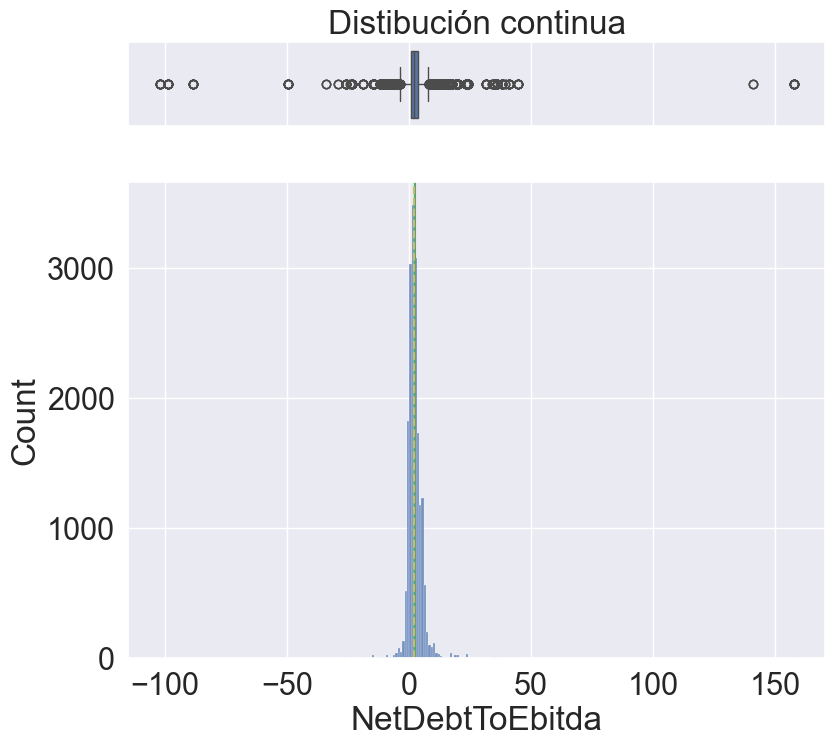

In [18]:
# Graficar
columna_a_graficar = 'NetDebtToEbitda' # indicar columna para el grafico
plot(df_transformed[columna_a_graficar])

In [19]:
# Transformaciones logarítmicas
columnas_a_transformar = [ 
    'CurrentRatio',
    'RelativeAssets',
    'RelativeRevenue'
    ]
for columna in columnas_a_transformar:
    df_transformed[f'{columna}_log'] = np.log(df_transformed[columna])
    df_transformed.drop(columna, axis=1, inplace=True)

# Coeficientes de asimetria actualizado
df_transformed.select_dtypes(include="number").skew().sort_values(ascending=False)

Dividends                 62.886274
FcfToEbitda               13.746321
Close                     13.148801
EnterpriseToEbitda        11.883762
MonthlyVariance           10.794743
CurrentDebt                9.420226
Revenue_QoQ                8.382512
MarketCap                  8.287131
Ebitda_QoQ                 8.276146
EnterpriseValue            8.149290
BasicAverageShares         7.561544
NetIncome                  7.285580
OperatingIncome            7.023449
FreeCashFlow               6.889848
OperatingCashFlow          6.633591
EBITDA                     6.398917
GrossProfit                6.280964
StockholdersEquity         5.846749
CashAndCashEquivalents     5.778002
TotalRevenue               5.112157
CurrentLiabilities         4.918812
Fcf_QoQ                    4.495654
Ebitda_YoY                 4.449741
CurrentAssets              4.334005
ReturnOnEquity             4.155228
Revenue_YoY                4.147109
TotalAssets                3.693064
TotalDebt                  3

In [20]:
# Definir columnas que saltean la "winsorización"
columnas_intactas = cols_monetarias + [
    'Close',    
    'TrailingPE',
    'EnterpriseToEbitda',
    'PriceToBook',
    'Date', 
    'Ticker',
    'Dividends'        
    ]

# Separar el dataset
df_passthrough = df_transformed[columnas_intactas].copy()
df_transformed_features = df_transformed.drop(columns=columnas_intactas)

## Gestión de Outliers

Se winsorizan los valores atipicos en las variables continuas que cumplan los siguientes criterios:

Para variables simetricas:
* A mas de 3 desviaciones tipicas de la media.
* Mas de 3 rangos intercuartilicos.

Para variables asimetricas (modulo del coeficiente de asimetrica mayor a 1):
* A mas de 3 MADs de la mediana.
* Mas de 3 rangos intercuartilicos.

In [21]:
# Outliers
df_cont_transformed = df_transformed_features.select_dtypes(include="number")
df_winsor = df_cont_transformed.apply(lambda x: gestiona_outliers(x, clas='winsor'))

OperatingMargins
ProfitMargins
ReturnOnEquity
ReturnOnAssets
DebtToEquity
Revenue_YoY
Revenue_QoQ
Ebitda_YoY
Ebitda_QoQ
Fcf_YoY
Fcf_QoQ
CapEx_YoY
CapEx_QoQ
NetDebtToEbitda
FcfToEbitda
CapExToRevenue
MonthlyReturn
MonthlyVariance
MarketCovariance
YearsSinceAdded
CurrentRatio_log
RelativeAssets_log
RelativeRevenue_log


In [22]:
# Coeficientes de asimetria luego de winsorizar
df_winsor.skew().sort_values(ascending=False)

CapEx_QoQ              2.619801
Fcf_QoQ                1.804513
MonthlyVariance        1.734691
CapExToRevenue         1.717872
YearsSinceAdded        1.029011
MarketCovariance       0.946825
RelativeRevenue_log    0.629975
ReturnOnAssets         0.568799
CurrentRatio_log       0.456322
OperatingMargins       0.454706
MonthlyReturn          0.433429
Fcf_YoY                0.430774
NetDebtToEbitda        0.350808
Revenue_YoY            0.296655
RelativeAssets_log     0.274606
Ebitda_YoY             0.230583
ProfitMargins          0.122723
DebtToEquity           0.104583
ReturnOnEquity         0.051390
FcfToEbitda           -0.237955
Ebitda_QoQ            -0.494188
CapEx_YoY             -0.603502
Revenue_QoQ           -2.344648
dtype: float64

Cont


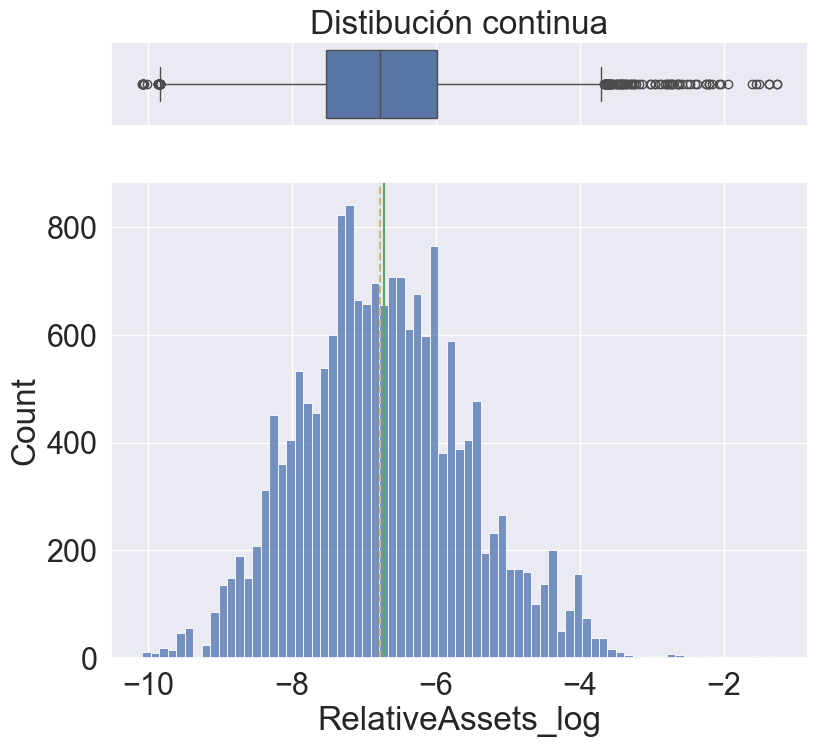

In [23]:
# Visualizar cambios
columna_a_graficar = 'RelativeAssets_log' # indicar columna para el grafico
plot(df_winsor[columna_a_graficar])

In [24]:
df_winsor.describe().T

,count,mean,std,min,25%,50%,75%,max
OperatingMargins,18028.0,1.893342e-01,0.141714,-0.398888,0.102476,0.177234,0.257621,0.741880
ProfitMargins,18028.0,1.342925e-01,0.130787,-0.353214,0.065358,0.120113,0.196847,0.603084
ReturnOnEquity,18028.0,1.868410e-01,0.308136,-0.600596,0.076708,0.158034,0.301991,0.981740
ReturnOnAssets,18028.0,7.846443e-02,0.077435,-0.227690,0.032310,0.062815,0.115332,0.388716
DebtToEquity,18028.0,9.335069e-01,1.544679,-3.052457,0.356205,0.720407,1.464997,4.798413
Revenue_YoY,18028.0,4.890767e-02,0.110679,-0.337165,-0.014486,0.051090,0.091761,0.439850
Revenue_QoQ,18028.0,1.584122e-07,0.000015,-0.000056,0.000000,0.000000,0.000000,0.000020
Ebitda_YoY,18028.0,7.050746e-02,0.236404,-0.506720,-0.009115,0.048369,0.148521,0.621617
Ebitda_QoQ,18028.0,1.251413e-05,0.000125,-0.000320,0.000000,0.000000,0.000000,0.000237
Fcf_YoY,18028.0,1.054311e-01,0.635743,-1.779000,-0.233857,0.039275,0.276144,1.866568


## Concatenación final de columnas

In [25]:
df_non_numeric_transformed = df_transformed_features.select_dtypes(exclude='number')
# Se unen variables contínuas transformadas y variables no numéricas
df_combined = pd.concat([df_non_numeric_transformed, df_winsor], axis=1)

# Unir con las columnas que fueron salteadas
df_final = pd.concat([df_passthrough, df_combined], axis=1)
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18028 entries, 0 to 18027
Data columns (total 54 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   CashAndCashEquivalents  18028 non-null  float64       
 1   CurrentDebt             18028 non-null  float64       
 2   LongTermDebt            18028 non-null  float64       
 3   TotalDebt               18028 non-null  float64       
 4   StockholdersEquity      18028 non-null  float64       
 5   TotalAssets             18028 non-null  float64       
 6   CurrentAssets           18028 non-null  float64       
 7   CurrentLiabilities      18028 non-null  float64       
 8   OperatingCashFlow       18028 non-null  float64       
 9   InvestingCashFlow       18028 non-null  float64       
 10  FinancingCashFlow       18028 non-null  float64       
 11  FreeCashFlow            18028 non-null  float64       
 12  CapitalExpenditure      18028 non-null  float6

In [26]:
# Guardar datos extraidos en fichero clean_data
df_final.to_parquet(f"{data_folder}/clean_data.parquet")